In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train.dtype  # an array

dtype('uint8')

In [ ]:
unique_values = np.unique(x_train)
print(unique_values)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

1. Normalization is essential in sigmoid and tanh activations, If we see the graph as x->inf the value of simoid is tending to 1, that makes the derivative zero. If we normalize the data the value of deriative is still larger than 0 and hence it makes convergence faster.
2. In deep neural networks without normalization, activation functions might explode.
3. If there is a lot of difference in scales of two features, the weight of one of the feature dominates and changes frequently.

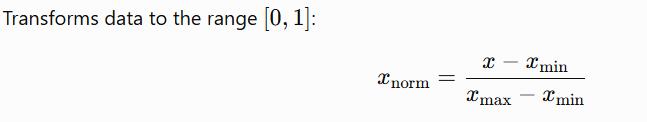

In [ ]:
print(x_train.shape)  # 3 dimensional array with 60000 training images and each image has 28 rows and 28 columns.

(60000, 28, 28)


In [ ]:
print(y_train.shape)

(60000,)


In [ ]:
print(x_test.shape)

(10000, 28, 28)


In [ ]:
print(y_test.shape)

(10000,)


In [ ]:
# Now to normalize it
# xmin = 0, xmax = 255 , so simply divide each value with 255
x_train = x_train/255
x_test = x_test/255

In [ ]:
print("feature matrix shape ",x_train.shape)
print("target matrix shape", y_train.shape)

feature matrix shape  (60000, 28, 28)
target matrix shape (60000,)


In [ ]:
x_train.shape

(60000, 28, 28)

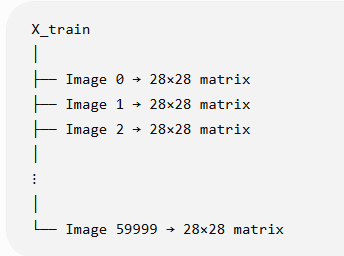

x_train[0] has 28 rows and 28 columns

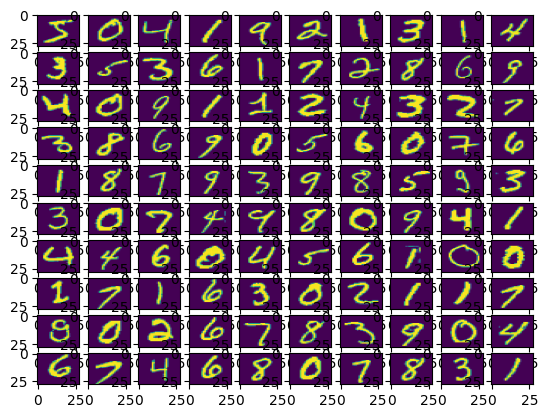

In [ ]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

1. fig is whole window, ax is thee area inside it
2. subplots will give the area into which the window is divided.
3. 2,2 => 2 rows and 2 columns.
4. ax is NOT an array.

Now, to pass to data to the neural network we shall flatten it. Also to compute weighted sum, X has to be a vector.

In [ ]:
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(256, activation = "relu"),
    Dense(128, activation = "relu"),
    Dense(10, activation = "softmax")
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
mod = model.fit(x_train, y_train, epochs=10,
          batch_size=2000,
          validation_split=0.2)

print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.2278 - loss: 2.2870 - val_accuracy: 0.3277 - val_loss: 2.2576
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3768 - loss: 2.1885 - val_accuracy: 0.4379 - val_loss: 2.0748
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4704 - loss: 1.9044 - val_accuracy: 0.5378 - val_loss: 1.6814
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5971 - loss: 1.4889 - val_accuracy: 0.6787 - val_loss: 1.2660
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6999 - loss: 1.1355 - val_accuracy: 0.7393 - val_loss: 0.9730
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7530 - loss: 0.9081 - val_accuracy: 0.7933 - val_loss: 0.7971
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.7908 - loss: 0.7664 - val_accuracy: 0.8194 - val_loss: 0.6854
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8159 - loss: 0.6694 - val_accuracy: 0.8384 - v

In [ ]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [47.89845657348633, 0.7129999995231628]


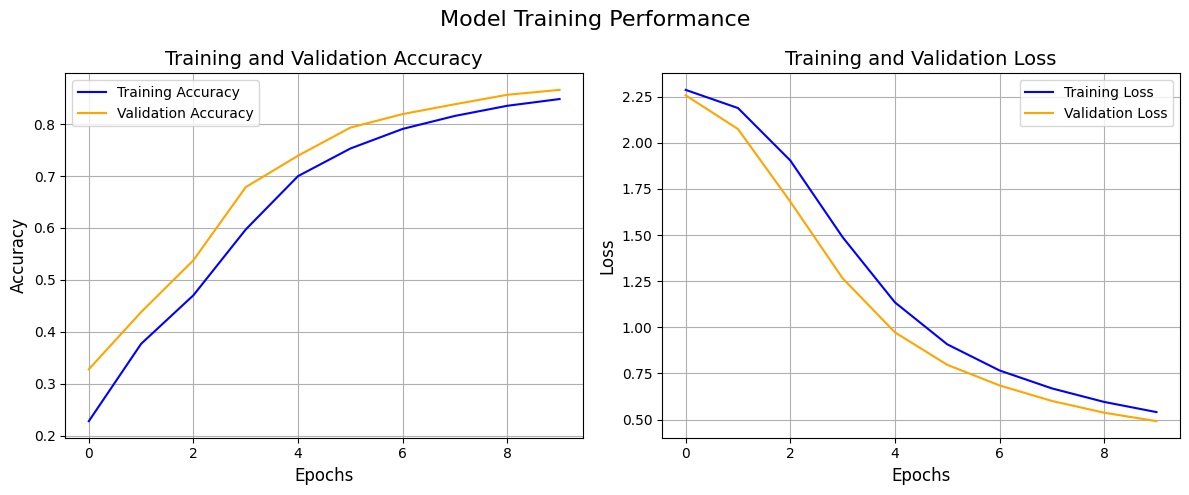

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()